In [1]:
import os

import pandas as pd
import numpy as np
import itertools
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import ScaledTranslation

from utils import (_load_capacity, 
                   _load_dispatch, 
                   _group_capacity_technologies, 
                   _group_dispatch_technologies)

from utils import (_load_GHG_emissions, 
                   _load_clean_energy, 
                   _load_losses, 
                   _load_land_use, 
                   _load_cost, 
                   _group_emissions_by_zone, 
                   _group_clean_energy_by_zone, 
                   _group_land_use_by_zone, 
                   _group_cost_by_zone, 
                   _group_demand_by_zone)


from viz import (_plot_new_and_existing_capacity, 
                 _plot_new_and_existing_storage, 
                 _plot_dispatch, 
                 _plot_total_cost, 
                 _plot_levelized_cost, 
                 _plot_carbon_emissions, 
                 _plot_carbon_emissions_intesity, 
                 _plot_clean_energy, 
                 _plot_land_use, 
                 _plot_available_land)

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = "Avenir"

path_to_scenarios = '/Users/Guille/Desktop/india_power/scenarios'
path_to_images    = '/Users/Guille/Desktop/india_power/images'
path_to_tables    = '/Users/Guille/Desktop/india_power/tables'
path_to_csvs      = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_input     = '/Users/Guille/Desktop/india_power/input_data/'

In [2]:
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
load_zones_  = pd.read_csv(path_to_input + r"/load_zones.csv").drop(columns = ['state', 'rps_zone'])

In [7]:
scen_csv_file = 'additional_1-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)


df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_ = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
#df_2_['clean_energy'] = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/pier
VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/additional
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/pier
VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ad

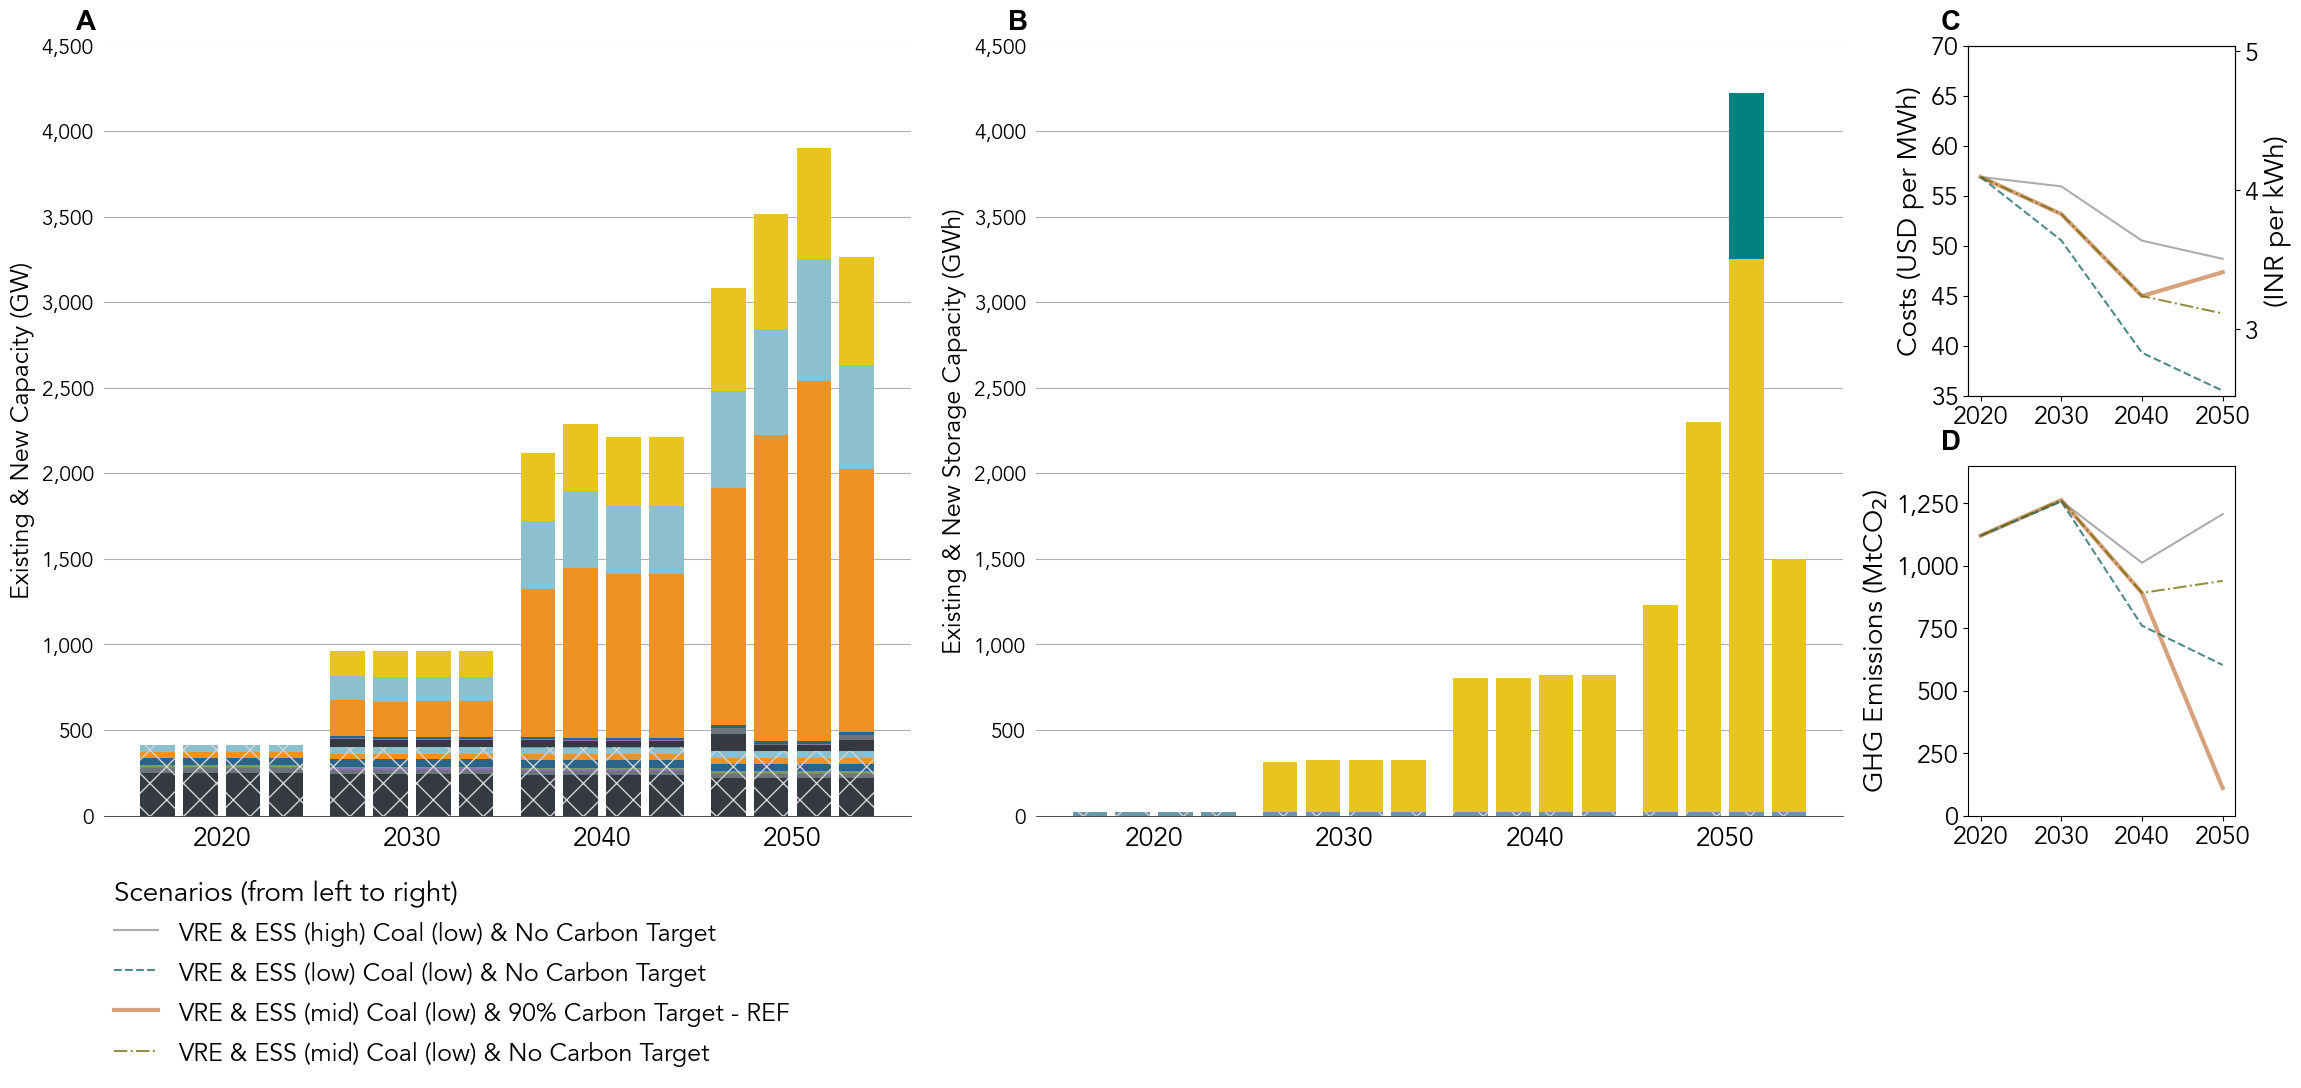

In [8]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 4500,
                               y_grid_inc = 500)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.75),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_1-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/SI-additional_1-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [9]:
scen_csv_file = 'additional_2-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)


df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_ = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
#clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
#df_2_['clean_energy'] = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost


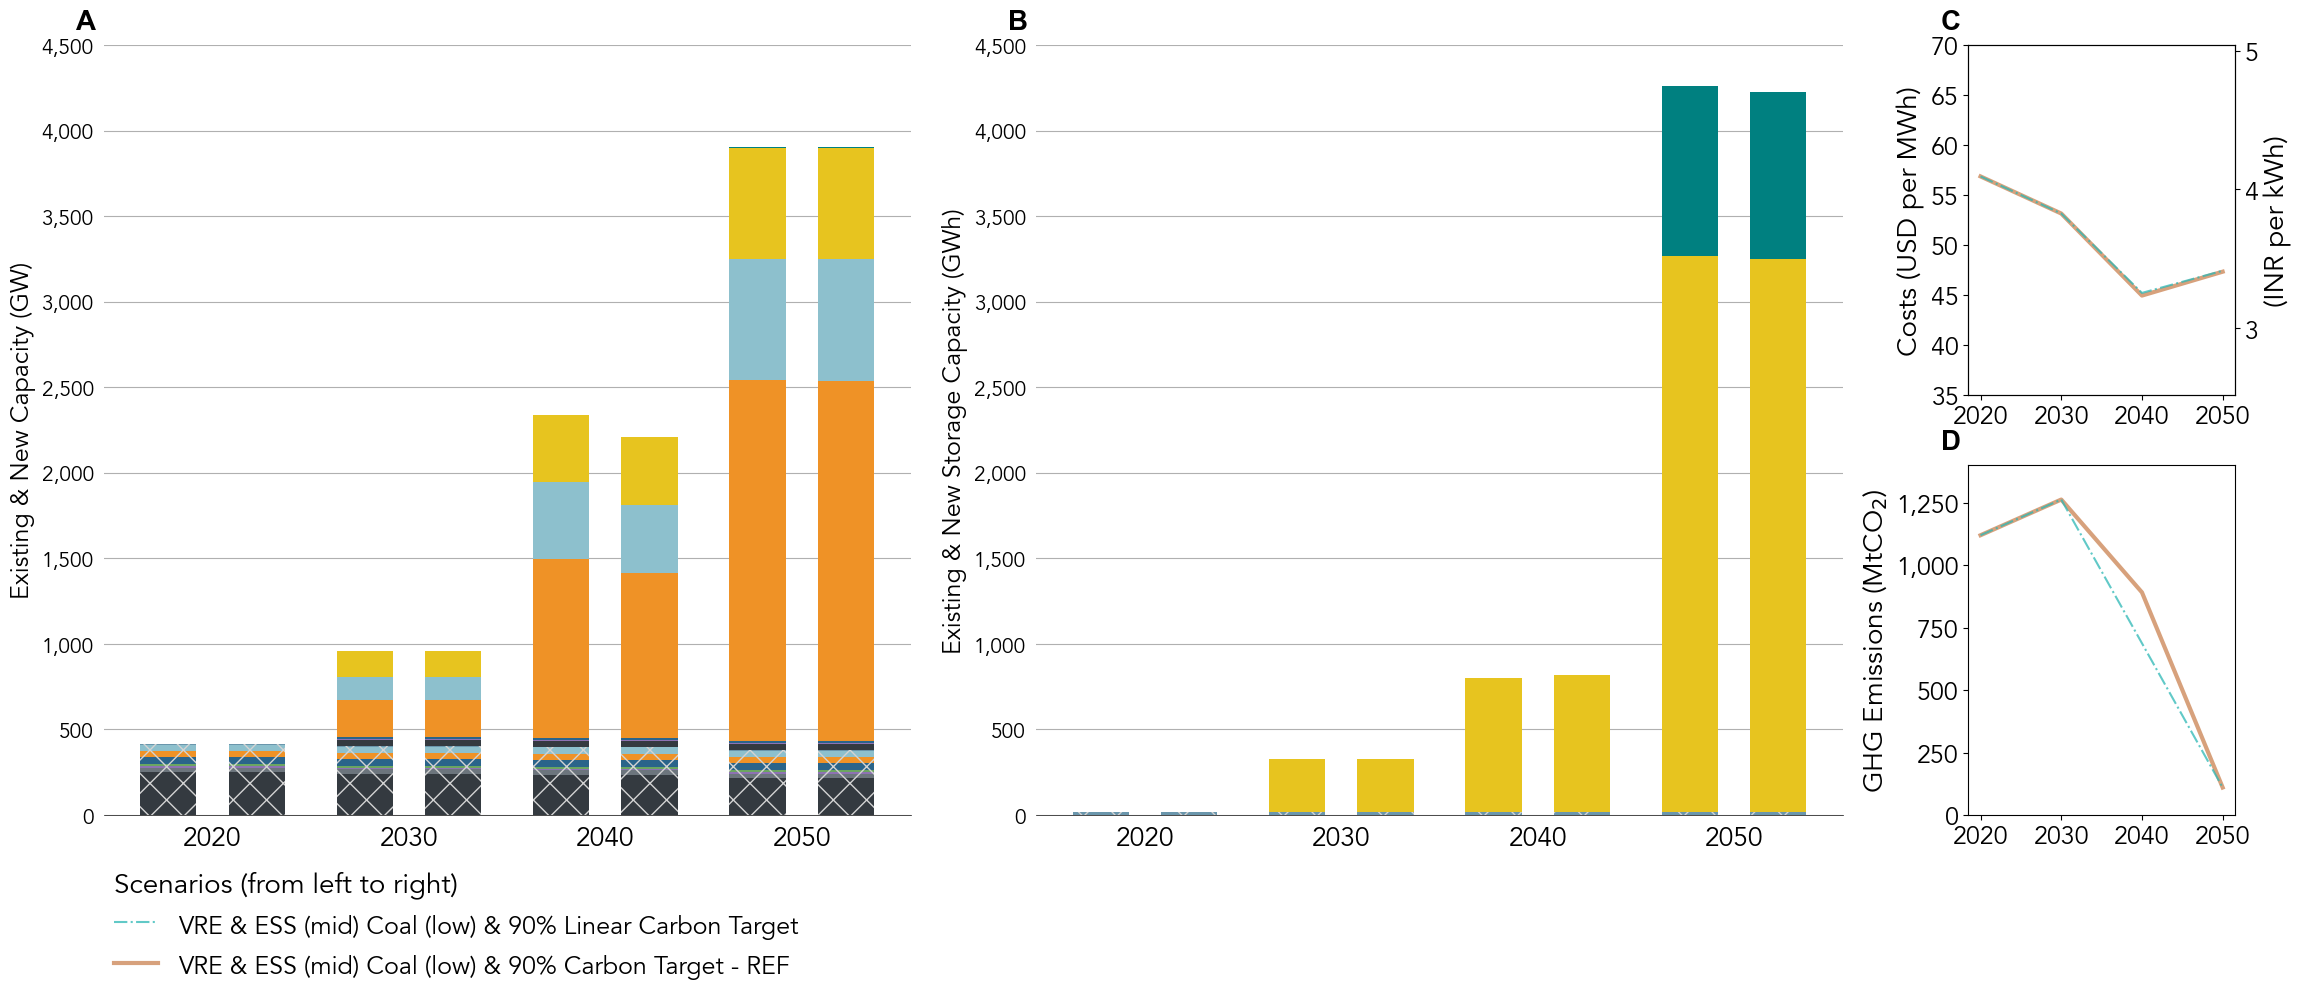

In [10]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 4500,
                               y_grid_inc = 500)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.5),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_2-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/SI-additional_2-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [9]:
# df_2_['system_cost']['total_cost'] = (df_2_['system_cost']['variable_cost']
#                                       + df_2_['system_cost']['fixed_cost']) + 5.9e9

# df_ = pd.merge(df_2_['system_cost'], df_2_['demand'], 
#                on = ['period', 'scenario', 'load_zone'],
#                how = 'left')

# df_['lcoe'] = df_['total_cost']/df_['load_mw']
# print(df_['scenario'].unique())

# idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid')
#         & (df_['period'] == 2040))

# print(df_.loc[idx_1_])

# idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
#         & (df_['period'] == 2040))

# print(df_.loc[idx_2_])

# print(100*(1. - df_.loc[idx_2_, 'lcoe'].to_numpy()/df_.loc[idx_1_, 'lcoe'].to_numpy()))

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']
   period                                           scenario load_zone  \
2    2040  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...       all   

   variable_cost    fixed_cost    total_cost       load_mw      lcoe  
2   2.790806e+10  1.571496e+11  1.909577e+11  4.188931e+09  45.58626  
   period                                           scenario load_zone  \
6    2040  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...       all   

   variable_cost    fixed_cost    total_cost       load_mw       lcoe  
6   3.435576e+10  1.493091e+11  1.895649e+11  4.188931e+09  45.253763  
[0.72938094]


In [11]:
scen_csv_file = 'additional_3-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_ = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
#clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
#df_2_['clean_energy'] = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost


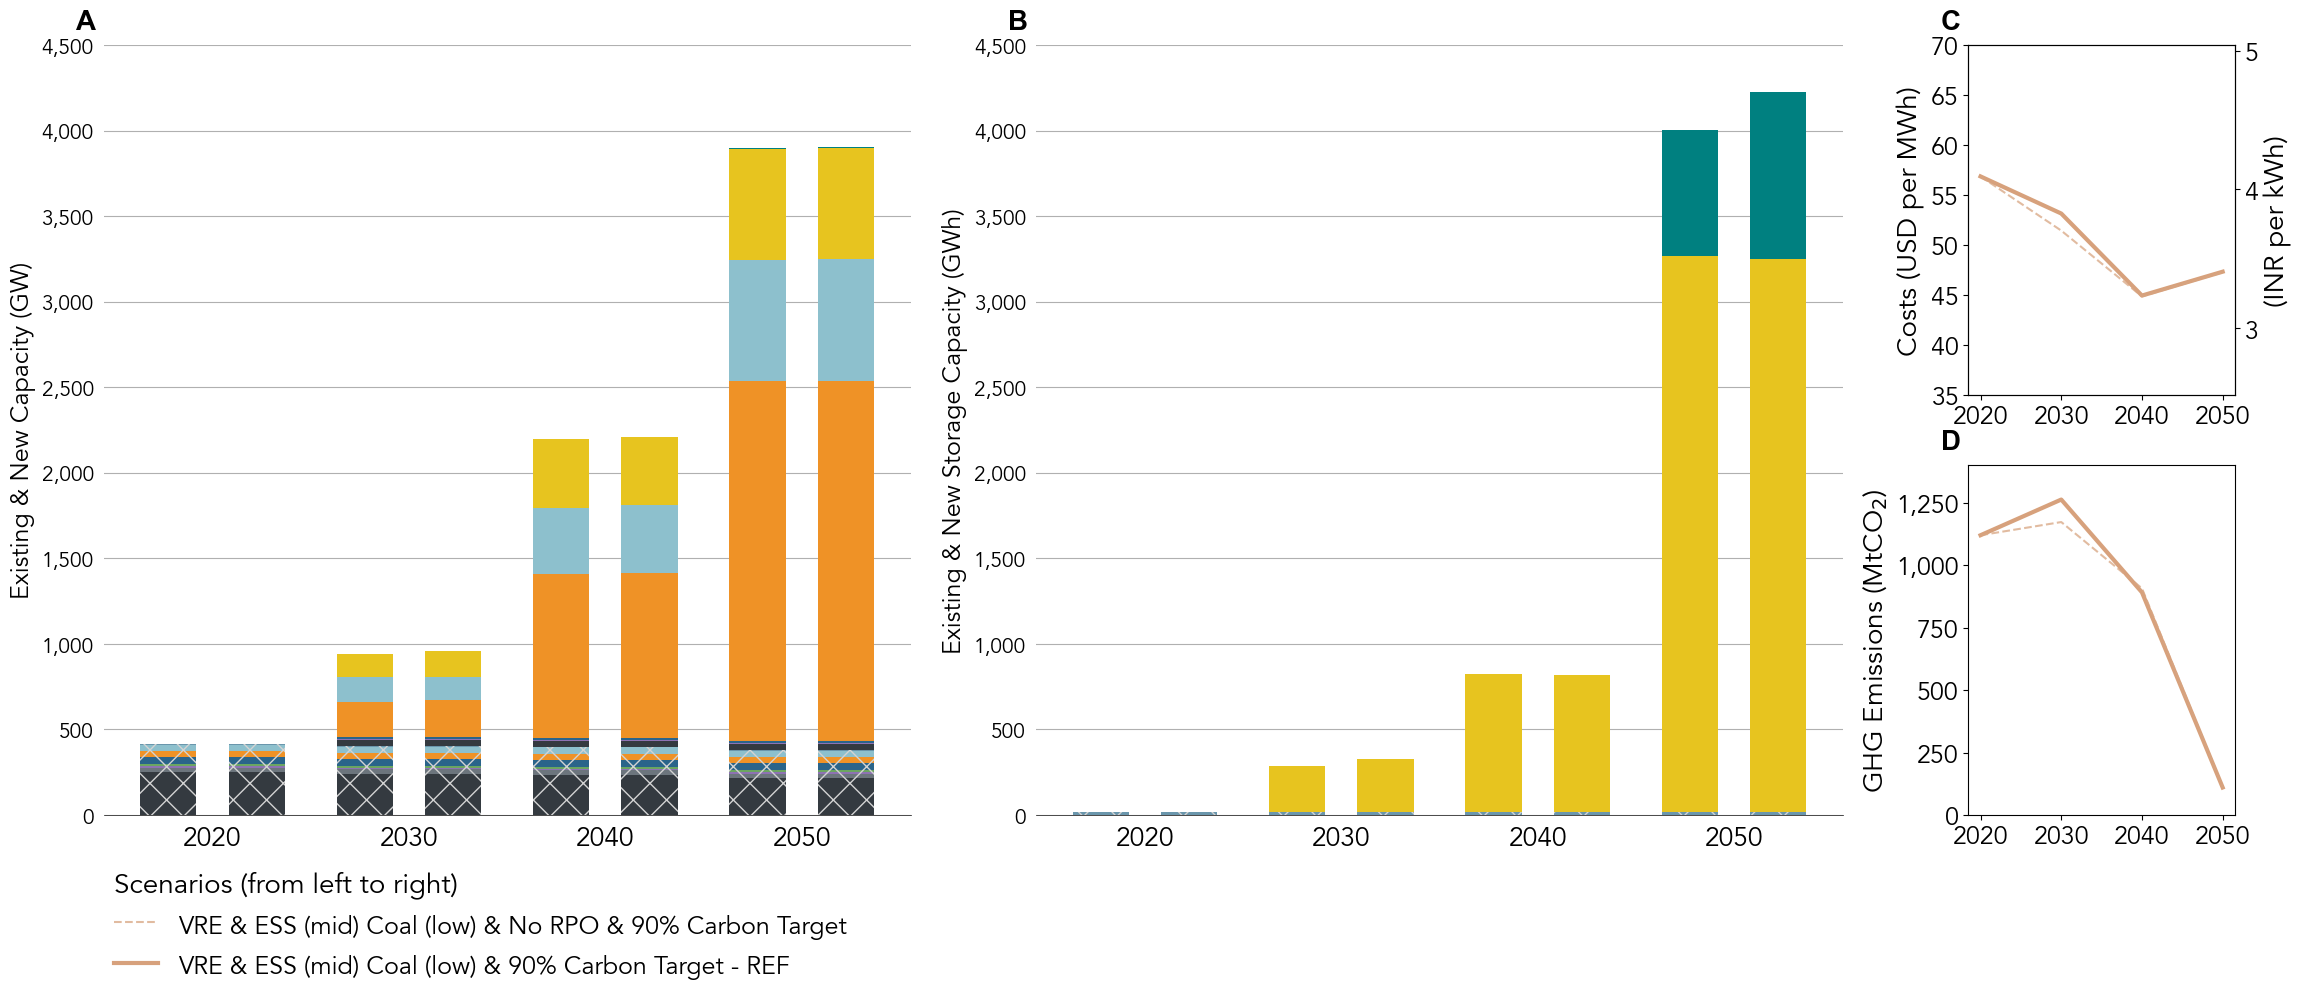

In [12]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 4500,
                               y_grid_inc = 500)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.5),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_3-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/SI-additional_3-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [13]:
scen_csv_file = 'additional_4-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)


df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_ = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])
#clean_         = _load_clean_energy(df_2_['scen_labels'])

df_2_['emissions'] = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])
#df_2_['clean_energy'] = _group_clean_energy_by_zone(clean_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost
VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/additional
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/cost


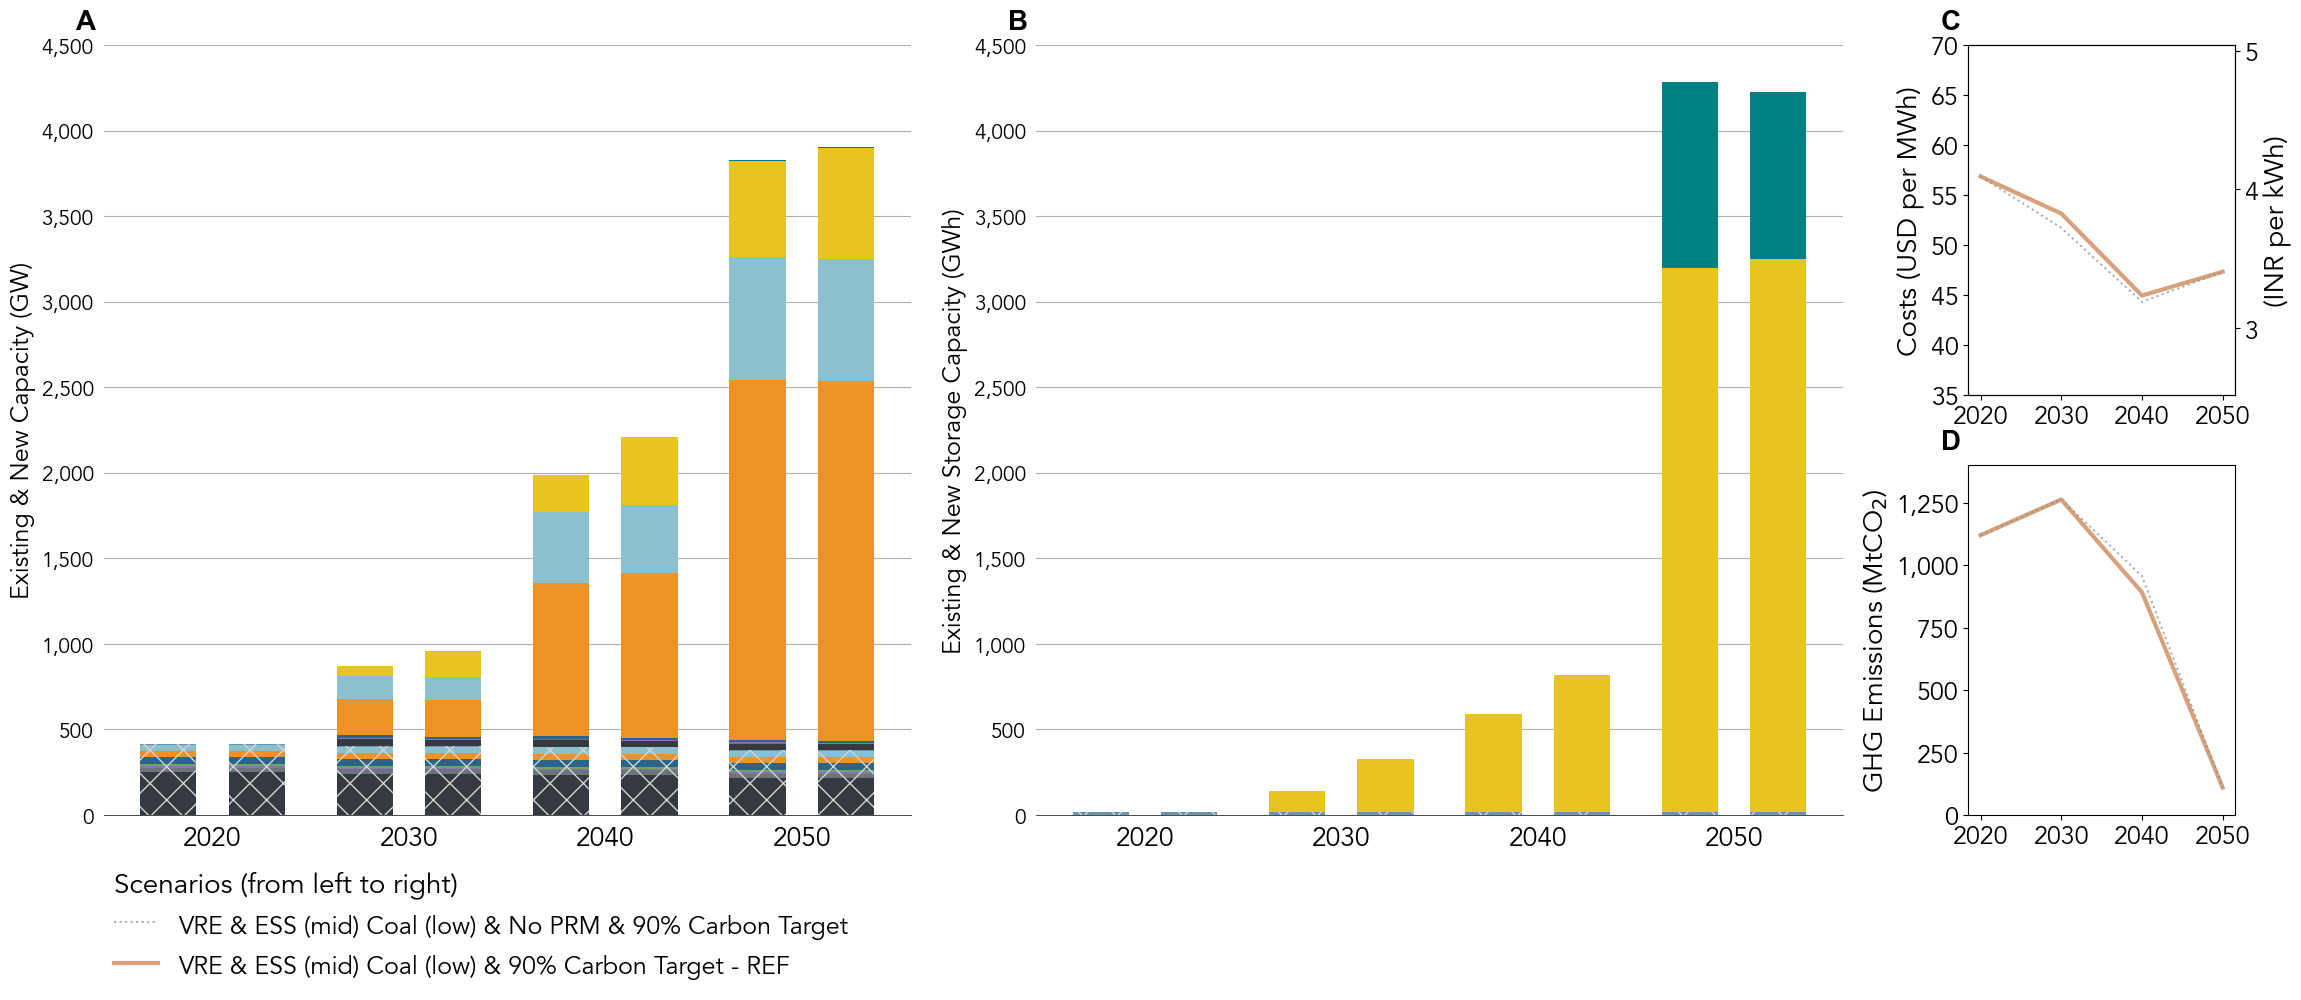

In [14]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 4500,
                                y_grid_inc = 500)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 4500,
                               y_grid_inc = 500)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.5),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-additional_4-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/SI-additional_4-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [15]:
scen_csv_file = 'ra_1-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])

df_2_['emissions'] = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_4PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_4PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_ST

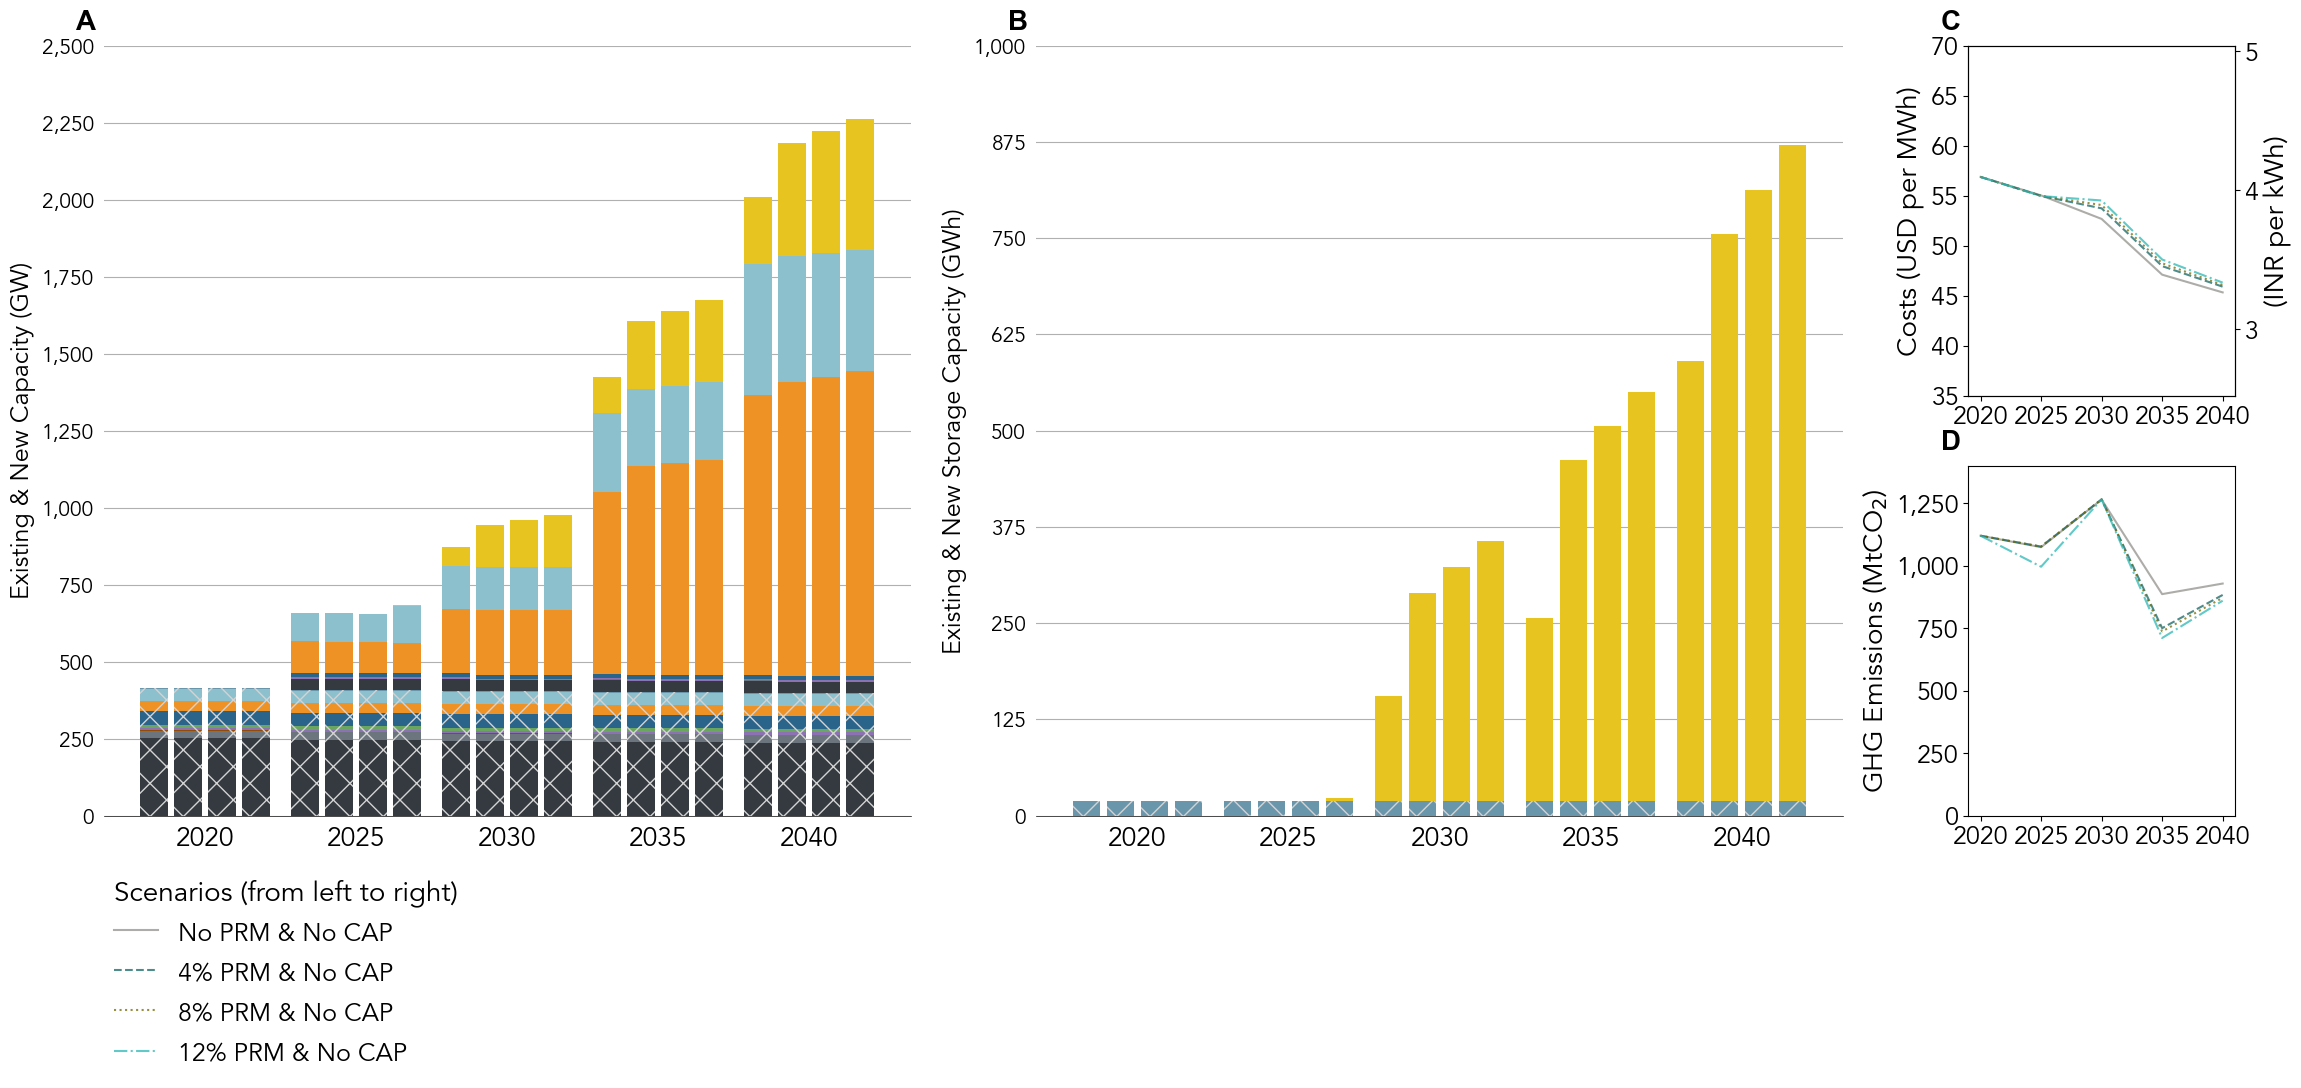

In [16]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 2500,
                                y_grid_inc = 250)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 1000,
                               y_grid_inc = 125)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.75),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-NoCAP-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/RA-NoCAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [17]:
scen_csv_file = 'ra_2-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])

df_2_['emissions'] = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_4PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_90LinCAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_4PRM_CC_50RPS_90LinCAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90LinCAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_90LinCAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_50RPS_90Lin

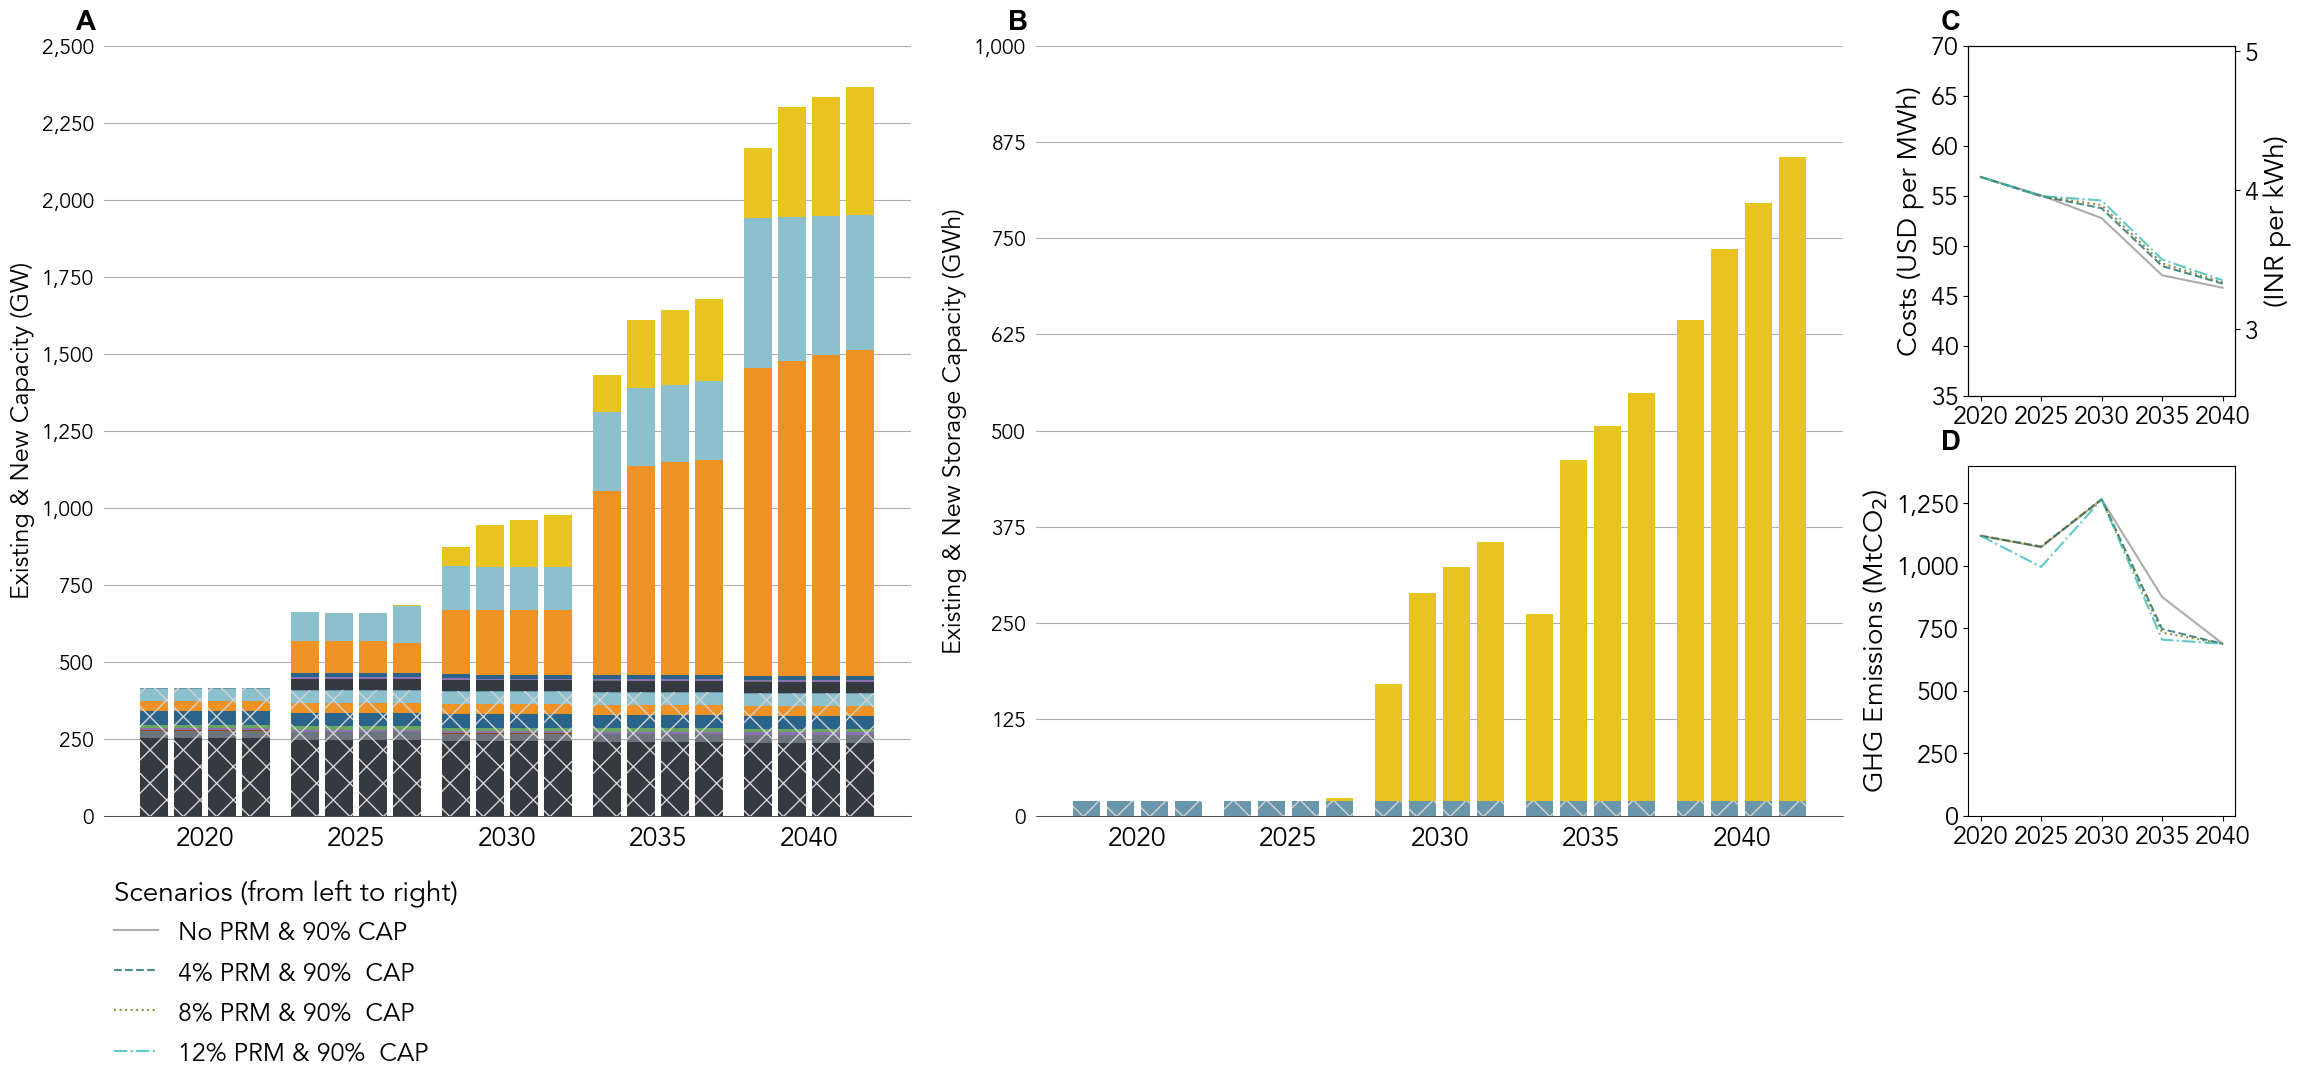

In [18]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 2500,
                                y_grid_inc = 250)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 1000,
                               y_grid_inc = 125)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.75),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-90CAP-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/RA-90CAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

In [19]:
scen_csv_file = 'ra_3-scenario_labels.csv'

df_1_ = {}
df_1_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

df_1_['capacity'] = _load_capacity(df_1_['scen_labels'])
df_1_['dispatch'] = _load_dispatch(df_1_['scen_labels'])
df_1_['capacity'] = _group_capacity_technologies(df_1_['capacity'], tech_labels_)
df_1_['dispatch'] = _group_dispatch_technologies(df_1_['dispatch'], tech_labels_)

df_2_ = {}
df_2_['scen_labels'] = pd.read_csv(path_to_csvs + '/' + scen_csv_file) 

emission_      = _load_GHG_emissions(df_2_['scen_labels'])
cost_, demand_ = _load_cost(df_2_['scen_labels'])

df_2_['emissions'] = _group_emissions_by_zone(emission_, df_2_['scen_labels'])
df_2_['system_cost'], df_2_['demand'] = _group_cost_by_zone(cost_, demand_, df_2_['scen_labels'])

# Add fixed cost of specified transmission capcity exogeously
df_2_['system_cost']['fixed_cost'] += 5.79e9

RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_90LinCAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90LinCAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_12PRM_CC_50RPS_90LinCAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/ra
RA2040_VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /

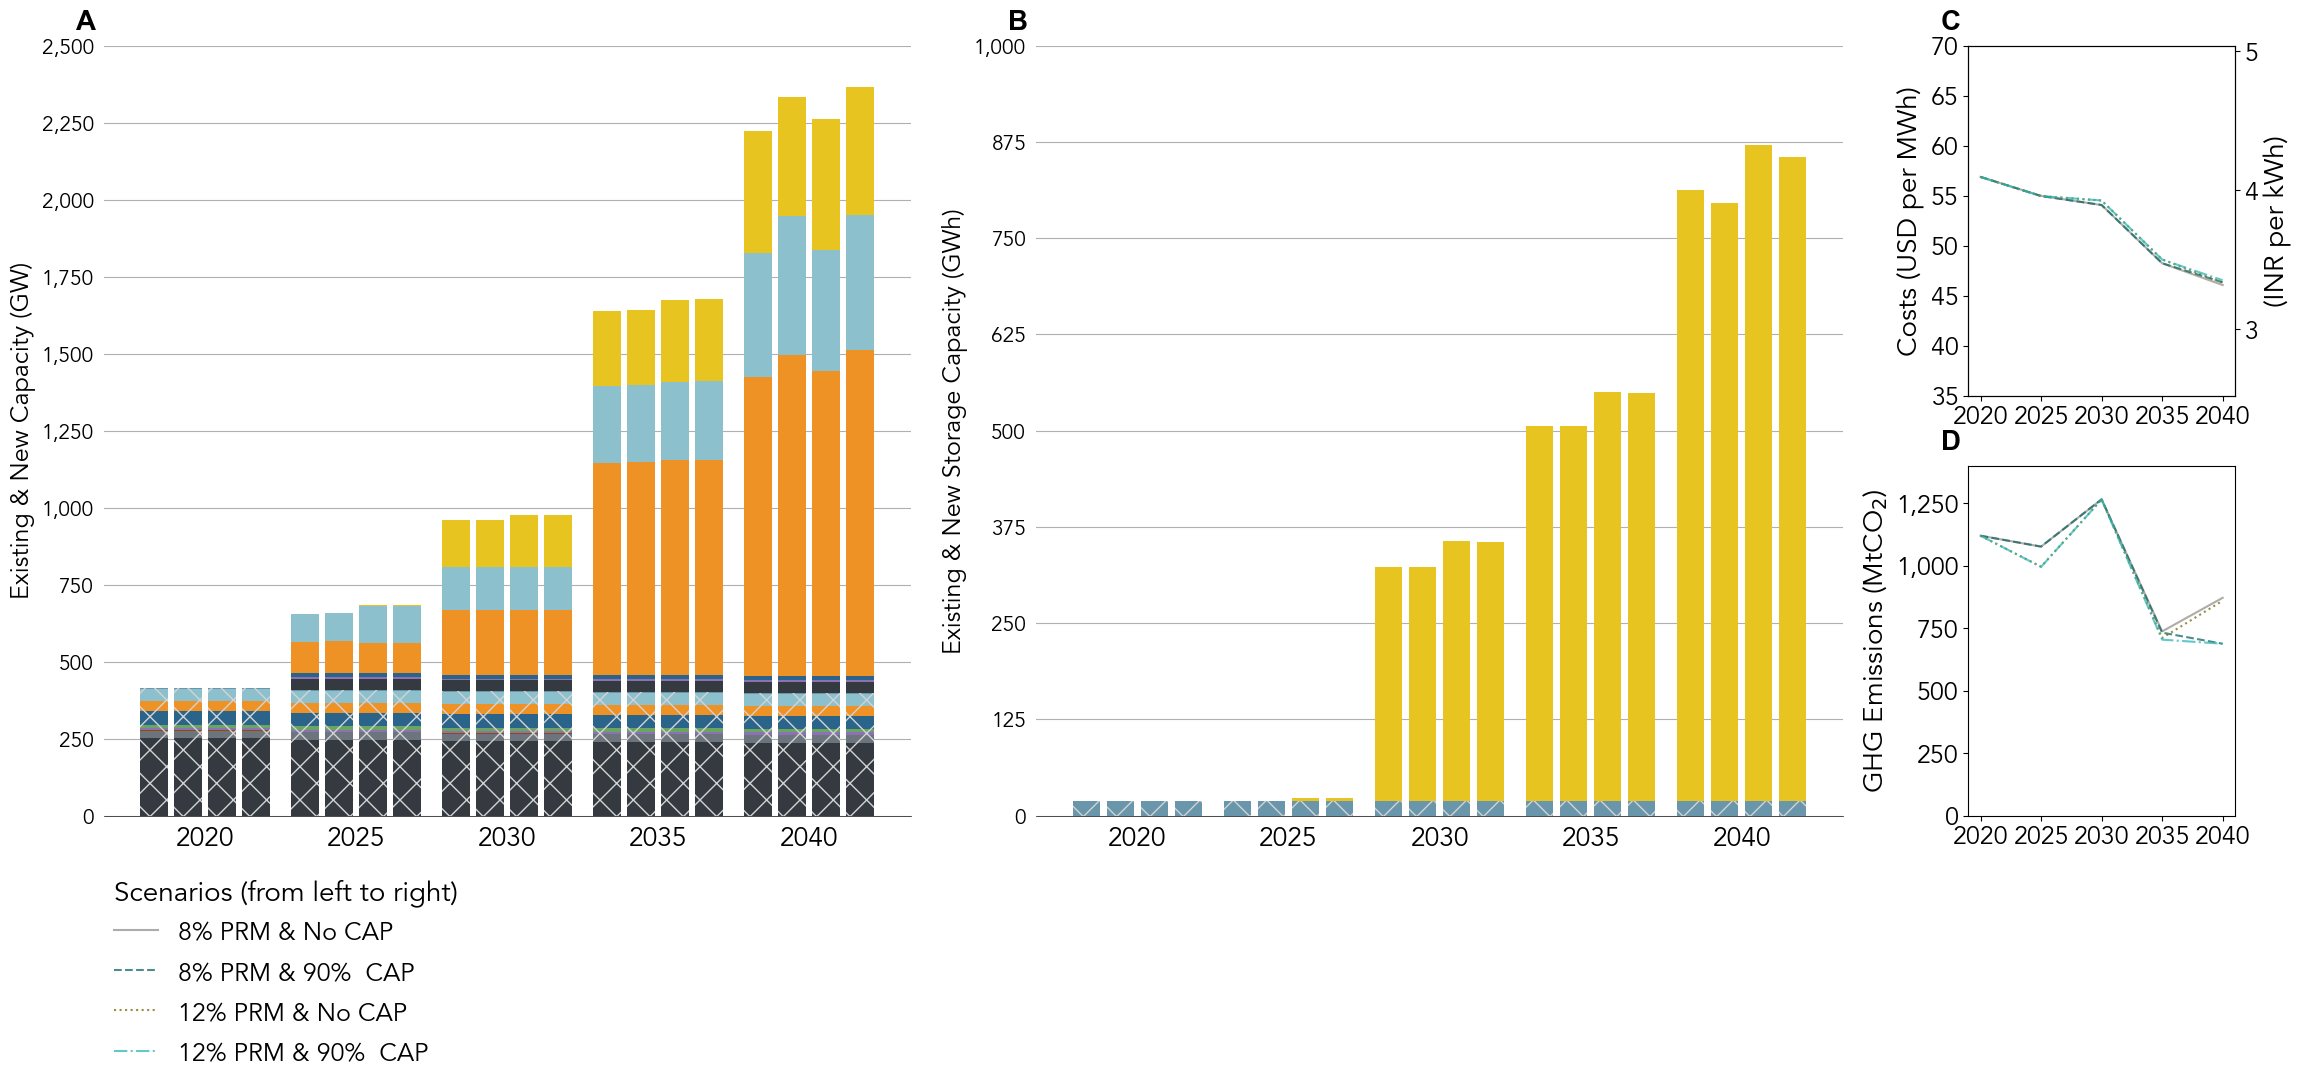

In [20]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'],
                               ['A', 'B', 'D']], 
                               figsize = (27.5, 10), 
                               gridspec_kw = {'wspace': .2,
                                              'width_ratios': [1, 1, .33]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 20, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

df_2_['scen_labels']['marker'] = None

_plot_new_and_existing_capacity(_ax['A'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                                ylabel     = 'Existing & New Capacity (GW)',
                                legend     = False,
                                y_lim_max  = 2500,
                                y_grid_inc = 250)

_plot_new_and_existing_storage(_ax['B'], df_1_['capacity'], df_1_['scen_labels'], tech_labels_,
                               ylabel     = 'Existing & New Storage Capacity (GWh)', 
                               legend     = False,
                               y_lim_max  = 1000,
                               y_grid_inc = 125)

# Plot levelized cost of electricity for different scenarios
_plot_levelized_cost(_ax['C'], df_2_['system_cost'], df_2_['demand'], df_2_['scen_labels'],                  
                     y_min  = 35,
                     y_max  = 70,
                     legend = False)

# Plot GHG emissions for different scenarios
_plot_carbon_emissions(_ax['D'], df_2_['emissions'], df_2_['scen_labels'], 
                       y_min  = 0,
                       y_max  = 1400,
                       legend = False)

leg = _ax['D'].legend(title          = 'Scenarios (from left to right)',
                      handlelength   = 1.75,
                      loc            = (-7., -0.75),
                      frameon        = False,
                      title_fontsize = 20,
                      prop           = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/RA-No90CAP-capacity_summary.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/RA-No90CAP-capacity_summary.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()